# C_S3.3 — Metric Selection via Permutation p-value

**Goal**: Find the smallest metric subset that achieves near-full detection power
while controlling false positive rate, using the same permutation p-value framework as S3.

**Framework**:
- For metric set $S$: $T_{\text{obs}} = \max(Z_m,\; m \in S)$
- Null distribution: $T_{\text{null}}$ from train true\_null cases
- $p = \frac{\#\{T_{\text{null}} \ge T_{\text{obs}}\} + 1}{N_{\text{null}} + 1}$
- Detect if $p \le \alpha$

**Structure**:
1. Data & split
2. Method validation (full metric set)
3. Individual metric power
4. Group ablation
5. Backward elimination & forward selection
6. Best-per-k summary
7. Final recommendation
8. **Driver analysis** — individual power vs max-Z contribution

In [1]:
from pathlib import Path
from itertools import combinations
import math, json, warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.patches import Patch

warnings.filterwarnings('ignore')
plt.rcParams.update({
    'figure.dpi': 120, 'figure.facecolor': 'white',
    'axes.grid': True, 'grid.alpha': 0.3,
})

S1_DIR  = Path('output/S1')
S3_DIR  = Path('output/S3')
OUT_DIR = Path('output/S3.1')
OUT_DIR.mkdir(parents=True, exist_ok=True)

ALPHA          = 0.05
TRAIN_FRACTION = 0.5
RANDOM_SEED    = 20260623

MAX_EXACT_K      = 5
MAX_EXACT_COMBOS = 155_000
MAX_SPARSE_K     = 8
BEAM_WIDTH       = 60

CATEGORY_WEIGHTS = {'mean_only': 1, 'variance_only': 1, 'mean+variance': 2}

# ── Metric filter toggles (shared with S3.0) ──
EXCLUDE_REVERSED = True   # 8 bw metrics: z↑ = no relationship, wrong for max-Z
EXCLUDE_WEAK     = False   # 9 metrics with signal/null separation < 0.5
EXCLUDE_RAW      = False   # 12 scale-dependent unbounded metrics
MERGE_DCOR_DCOV  = False   # remove dcov (mathematically redundant with dcor)

GROUP_COLORS = {
    'correlation': '#e11d48', 'distance': '#7c3aed', 'slope': '#64748b',
    'bin': '#0891b2', 'distribution': '#059669', 'mine': '#d97706', 'nonlinear': '#2563eb',
}
GROUP_LABELS = {
    'correlation': 'Correlation', 'distance': 'Distance', 'slope': 'Slope',
    'bin': 'Binning', 'distribution': 'Distribution', 'mine': 'MINE', 'nonlinear': 'Nonlinear',
}

## §1 Load data & train/validation split

In [2]:
df = pd.read_parquet(S3_DIR / 'permutation_all.parquet')
Z_COLS = sorted([c for c in df.columns if c.startswith('z_')])

cases_main = pd.read_csv(S1_DIR / 'cases.csv', low_memory=False)
cases_null = pd.read_csv(S1_DIR / 'null_expanded_cases.csv', low_memory=False)
cases_null['case_id'] = cases_null['case_id'] + cases_main['case_id'].max()

meta_cols = ['case_id', 'family_id', 'snr', 'spread_pattern', 'x_distribution']
cases_all = pd.concat([cases_main[meta_cols], cases_null[meta_cols]], ignore_index=True)
df = df.merge(cases_all, on='case_id', how='left')

is_null = df['family_id'] == 'Null'
is_const = df['spread_pattern'] == 'constant'
df['category'] = 'mean+variance'
df.loc[is_null & is_const, 'category'] = 'true_null'
df.loc[is_null & ~is_const, 'category'] = 'variance_only'
df.loc[~is_null & is_const, 'category'] = 'mean_only'

rng = np.random.default_rng(RANDOM_SEED)
df['split'] = 'validation'
for _, idx in df.groupby(['category', 'x_distribution'], dropna=False).groups.items():
    idx = np.array(list(idx)).copy()
    rng.shuffle(idx)
    n_train = max(1, min(int(round(len(idx) * TRAIN_FRACTION)), len(idx) - 1))
    df.loc[idx[:n_train], 'split'] = 'train'

train = df[df['split'] == 'train'].copy()
validation = df[df['split'] == 'validation'].copy()

print(f'Total: {len(df):,} cases, {len(Z_COLS)} z-score metrics')
print(f'Train: {len(train):,}  Validation: {len(validation):,}')
print(df.groupby(['split', 'category']).size().unstack(fill_value=0))

Total: 44,300 cases, 45 z-score metrics
Train: 22,150  Validation: 22,150
category    mean_only  true_null  variance_only
split                                          
train           22110         10             30
validation      22110         10             30


## §2 Metric groups & calibration screen

Remove redundant (dcov ≈ dcor) and degenerate (MCN) metrics, then screen
for null-calibration pathologies (bias, low variance, instability).

In [3]:
METRIC_GROUPS = {}
GROUP_DEFS = {
    'correlation': ['z_abs_pearson_r', 'z_abs_spearman_rho', 'z_abs_covariance'],
    'distance':    ['z_dcor', 'z_dcov'],
    'mine':        ['z_mic', 'z_mas', 'z_mev', 'z_mcn', 'z_mic_minus_r2'],
    'bin':         [c for c in Z_COLS if 'bin' in c],
    'distribution':['z_ec_dist_ks', 'z_ec_dist_wass', 'z_ew_dist_ks', 'z_ew_dist_wass'],
    'nonlinear':   ['z_lowess_r2'],
    'slope':       [c for c in Z_COLS if 'ep_' in c or 'pf_' in c or 'seg_' in c],
}
for g, cols in GROUP_DEFS.items():
    for c in cols:
        if c in Z_COLS:
            METRIC_GROUPS[c] = g

NICE = {
    'z_abs_pearson_r': '|Pearson|', 'z_abs_spearman_rho': '|Spearman|',
    'z_abs_covariance': 'Covariance', 'z_dcor': 'dcor', 'z_dcov': 'dcov',
    'z_mic': 'MIC', 'z_mas': 'MAS', 'z_mev': 'MEV', 'z_mcn': 'MCN',
    'z_mic_minus_r2': 'MIC-r2',
    'z_ec_bin_eta2': 'eta2(EC)', 'z_ew_bin_eta2': 'eta2(EW)',
    'z_ec_dist_ks': 'KS(EC)', 'z_ec_dist_wass': 'Wass(EC)',
    'z_ew_dist_ks': 'KS(EW)', 'z_ew_dist_wass': 'Wass(EW)',
    'z_lowess_r2': 'LOWESS R2',
}
METRIC_DISPLAY = {c: NICE.get(c, c.replace('z_', '')) for c in Z_COLS}

# ── Apply metric filter toggles ──
_reversed = {c for c in Z_COLS if '_bin_bw_' in c}
_weak = {c for c in Z_COLS
         if any(c.endswith(s) for s in ['_ep_early', '_ep_mid', '_ep_late'])
         or c in ('z_raw_seg_strength', 'z_std_seg_strength', 'z_mcn')}
_raw = {c for c in Z_COLS
        if c.startswith('z_abs_raw_') or c == 'z_raw_seg_strength'
        or c == 'z_abs_covariance' or '_bin_amp' in c}

exclude = set()
if EXCLUDE_REVERSED: exclude |= _reversed
if EXCLUDE_WEAK:     exclude |= _weak
if EXCLUDE_RAW:      exclude |= _raw
if MERGE_DCOR_DCOV and 'z_dcov' in Z_COLS:
    exclude.add('z_dcov')

SAFE_METRICS = [c for c in Z_COLS if c in METRIC_GROUPS and c not in exclude]

print(f'Metric filtering: {len(Z_COLS)} total → {len(SAFE_METRICS)} safe '
      f'(excluded {len(exclude)}: '
      f'reversed={len(_reversed & exclude)}, weak={len(_weak & exclude)}, '
      f'raw={len(_raw & exclude)}, dcov={1 if "z_dcov" in exclude else 0})')

# ── Null-calibration screen ──
train_null = train[train['category'] == 'true_null']
flagged = []
for zc in list(SAFE_METRICS):
    z_null = train_null[zc].dropna()
    if len(z_null) < 10:
        flagged.append((zc, 'too few'))
    elif abs(z_null.mean()) > 1.0:
        flagged.append((zc, f'bias={z_null.mean():.2f}'))
    elif z_null.std() < 0.3:
        flagged.append((zc, f'degen std={z_null.std():.2f}'))
    elif z_null.std() > 3.0:
        flagged.append((zc, f'unstable std={z_null.std():.2f}'))
for m, reason in flagged:
    SAFE_METRICS.remove(m)
    print(f'Removed {METRIC_DISPLAY[m]}: {reason}')

print(f'\nFinal: {len(SAFE_METRICS)} safe metrics')
for m in SAFE_METRICS:
    print(f'  {METRIC_DISPLAY[m]:20s}  ({METRIC_GROUPS[m]})')

Metric filtering: 45 total → 37 safe (excluded 8: reversed=8, weak=0, raw=0, dcov=0)
Removed LOWESS R2: too few
Removed MAS: too few
Removed MCN: too few
Removed MEV: too few
Removed MIC: too few
Removed MIC-r2: too few

Final: 31 safe metrics
  Covariance            (correlation)
  |Pearson|             (correlation)
  abs_raw_ep_early      (slope)
  abs_raw_ep_late       (slope)
  abs_raw_ep_mid        (slope)
  abs_raw_ep_overall    (slope)
  abs_raw_pf_early      (slope)
  abs_raw_pf_late       (slope)
  abs_raw_pf_mid        (slope)
  abs_raw_pf_overall    (slope)
  |Spearman|            (correlation)
  abs_std_ep_early      (slope)
  abs_std_ep_late       (slope)
  abs_std_ep_mid        (slope)
  abs_std_ep_overall    (slope)
  abs_std_pf_early      (slope)
  abs_std_pf_late       (slope)
  abs_std_pf_mid        (slope)
  abs_std_pf_overall    (slope)
  dcor                  (distance)
  dcov                  (distance)
  ec_bin_amp            (bin)
  eta2(EC)              (bin)


## §3 Detection & evaluation functions

Detection rule (same as S3):
- $T = \max(Z_m,\; m \in S)$
- $p = \frac{\#\{T_{\text{null}} \ge T_{\text{obs}}\} + 1}{N_{\text{null}} + 1}$
- Detect if $p \le \alpha$

FPR is measured on **true\_null only**.
Macro power = weighted mean: mean\_only(\times 2) + variance\_only(\times 1) + mean+variance(\times 2).

In [4]:
def compute_null_T(data, z_metrics):
    null_data = data[data['category'] == 'true_null']
    return np.sort(null_data[z_metrics].max(axis=1).dropna().values)

def compute_pvalues(T_obs_values, null_T_sorted):
    n = len(null_T_sorted)
    ranks = np.searchsorted(null_T_sorted, T_obs_values, side='left')
    return (n - ranks + 1) / (n + 1)

def evaluate(z_metrics, data_fit, data_eval, alpha=ALPHA):
    z_metrics = list(z_metrics)
    null_T = compute_null_T(data_fit, z_metrics)
    T_eval = data_eval[z_metrics].max(axis=1).values
    p_eval = compute_pvalues(T_eval, null_T)
    detected = p_eval <= alpha
    cat_vals = data_eval['category'].values
    out = {}
    for cat in ['true_null', 'mean_only', 'variance_only', 'mean+variance']:
        mask = cat_vals == cat
        out[f'rate_{cat}'] = float(detected[mask].mean()) if mask.sum() else np.nan
    return out

def macro_power(result):
    pairs = [(result[f'rate_{cat}'], CATEGORY_WEIGHTS[cat]) for cat in CATEGORY_WEIGHTS]
    valid = [(r, w) for r, w in pairs if not np.isnan(r)]
    return sum(r * w for r, w in valid) / sum(w for _, w in valid) if valid else np.nan

def make_row(z_metrics, label=None, kind=None):
    z_metrics = list(z_metrics)
    tr = evaluate(z_metrics, train, train)
    va = evaluate(z_metrics, train, validation)
    return {
        'label': label or ', '.join(METRIC_DISPLAY.get(m, m) for m in z_metrics),
        'kind': kind or 'combo',
        'k': len(z_metrics),
        'metrics': ','.join(z_metrics),
        'display_metrics': ', '.join(METRIC_DISPLAY.get(m, m) for m in z_metrics),
        'train_macro_power': macro_power(tr),
        'train_FPR': tr['rate_true_null'],
        'val_macro_power': macro_power(va),
        'val_FPR': va['rate_true_null'],
        'val_MO': va['rate_mean_only'],
        'val_VO': va['rate_variance_only'],
        'val_MV': va['rate_mean+variance'],
    }

print('Detection: T = max(Z), p = (#null >= obs + 1)/(N+1), detect if p <= alpha')
print(f'FPR target: {ALPHA}')
print(f'Macro power weights: {CATEGORY_WEIGHTS}')

Detection: T = max(Z), p = (#null >= obs + 1)/(N+1), detect if p <= alpha
FPR target: 0.05
Macro power weights: {'mean_only': 1, 'variance_only': 1, 'mean+variance': 2}


## §4 Method validation — full metric set

Before selecting metrics, verify the method works: FPR should be near alpha,
power should be high for signal categories.

In [5]:
baseline = make_row(SAFE_METRICS, label='all_safe', kind='baseline')
FULL_POWER = baseline['val_macro_power']

print(f'Null calibration: {len(train[train["category"]=="true_null"]):,} train true_null cases')
print(f'\n--- All {len(SAFE_METRICS)} metrics ---')
print(f'  Validation macro power: {FULL_POWER:.4f}')
print(f'  Validation FPR:         {baseline["val_FPR"]:.4f}  (target: {ALPHA})')
print(f'  mean_only:              {baseline["val_MO"]:.4f}')
print(f'  variance_only:          {baseline["val_VO"]:.4f}')
print(f'  mean+variance:          {baseline["val_MV"]:.4f}')

Null calibration: 10 train true_null cases

--- All 31 metrics ---
  Validation macro power: 0.0000
  Validation FPR:         0.0000  (target: 0.05)
  mean_only:              0.0000
  variance_only:          0.0000
  mean+variance:          nan


posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values
posx and posy should be finite values


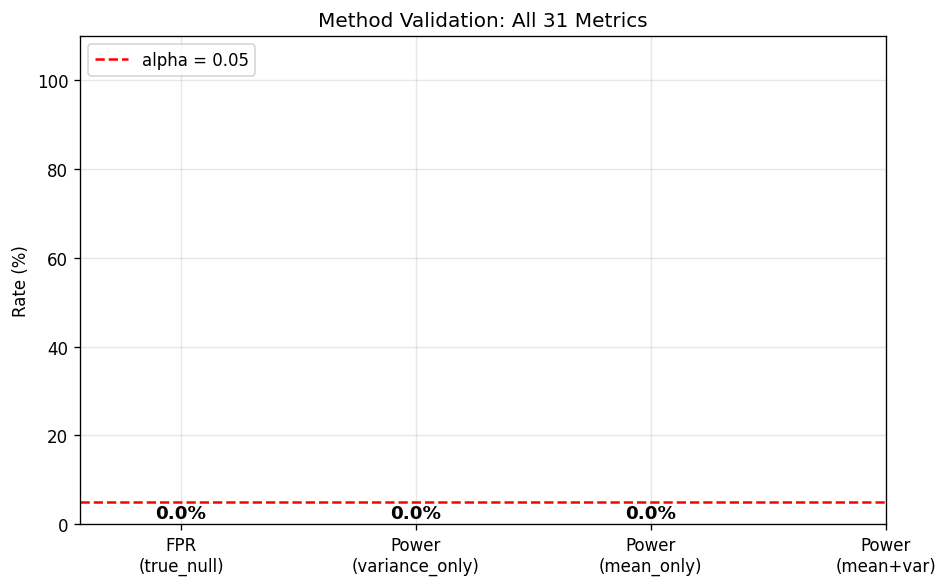

In [6]:
cat_order = ['true_null', 'variance_only', 'mean_only', 'mean+variance']
bar_labels = ['FPR\n(true_null)', 'Power\n(variance_only)', 'Power\n(mean_only)', 'Power\n(mean+var)']
bar_colors = ['#ef4444', '#f59e0b', '#22c55e', '#3b82f6']
rates = [baseline['val_FPR'], baseline['val_VO'], baseline['val_MO'], baseline['val_MV']]

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(range(4), [r * 100 for r in rates], color=bar_colors, edgecolor='white', width=0.6)
ax.axhline(ALPHA * 100, color='red', ls='--', lw=1.5, label=f'alpha = {ALPHA}')
ax.set_xticks(range(4))
ax.set_xticklabels(bar_labels)
ax.set_ylabel('Rate (%)')
ax.set_title(f'Method Validation: All {len(SAFE_METRICS)} Metrics')
for i, r in enumerate(rates):
    ax.text(i, r * 100 + 1.5, f'{r:.1%}', ha='center', fontweight='bold', fontsize=11)
ax.set_ylim(0, 110)
ax.legend(fontsize=10)
plt.tight_layout()
fig.savefig(OUT_DIR / 'method_validation.png', dpi=200, bbox_inches='tight')
plt.show()

## §5 Individual metric power (k=1)

In [7]:
individual_rows = []
for m in SAFE_METRICS:
    row = make_row([m], label=METRIC_DISPLAY[m], kind='individual')
    row['group'] = METRIC_GROUPS[m]
    individual_rows.append(row)

individual = pd.DataFrame(individual_rows).sort_values('train_macro_power', ascending=False)
individual.to_csv(OUT_DIR / 'individual_metrics.csv', index=False, float_format='%.6f')

cols = ['label', 'group', 'val_macro_power', 'val_FPR', 'val_MO', 'val_VO', 'val_MV']
print(individual[cols].to_string(index=False, float_format='{:.3f}'.format))

             label        group  val_macro_power  val_FPR  val_MO  val_VO  val_MV
        Covariance  correlation            0.000    0.000   0.000   0.000     NaN
   abs_std_pf_late        slope            0.000    0.000   0.000   0.000     NaN
  raw_seg_strength        slope            0.000    0.000   0.000   0.000     NaN
          Wass(EW) distribution            0.000    0.000   0.000   0.000     NaN
            KS(EW) distribution            0.000    0.000   0.000   0.000     NaN
          eta2(EW)          bin            0.000    0.000   0.000   0.000     NaN
        ew_bin_amp          bin            0.000    0.000   0.000   0.000     NaN
          Wass(EC) distribution            0.000    0.000   0.000   0.000     NaN
            KS(EC) distribution            0.000    0.000   0.000   0.000     NaN
          eta2(EC)          bin            0.000    0.000   0.000   0.000     NaN
        ec_bin_amp          bin            0.000    0.000   0.000   0.000     NaN
              dc

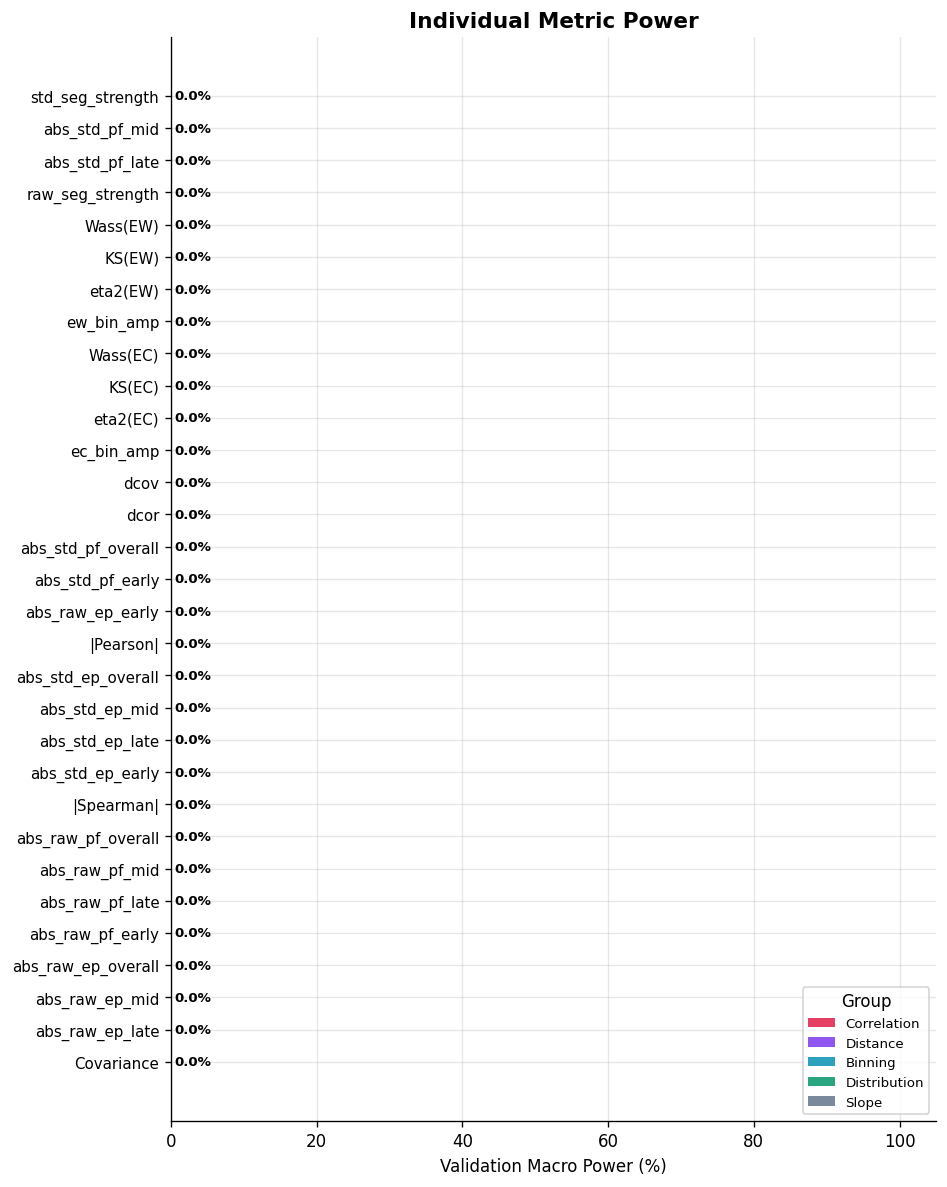

In [8]:
fig, ax = plt.subplots(figsize=(8, 10))
ind = individual.sort_values('val_macro_power', ascending=True).copy()
names = ind['label'].values
powers_i = ind['val_macro_power'].values * 100
colors = [GROUP_COLORS.get(g, '#999') for g in ind['group'].values]

ax.barh(range(len(names)), powers_i, color=colors, alpha=0.85, height=0.6)
for i, p in enumerate(powers_i):
    ax.text(p + 0.5, i, f'{p:.1f}%', va='center', fontsize=8, fontweight='bold')

ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=9)
ax.axvline(FULL_POWER * 100, color='gray', ls=':', lw=1.2, label=f'All metrics: {FULL_POWER:.1%}')
ax.set_xlabel('Validation Macro Power (%)')
ax.set_xlim(0, 105)
ax.set_title('Individual Metric Power', fontsize=13, fontweight='bold')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

seen = []
handles = []
for g in ind['group'].values[::-1]:
    if g not in seen:
        seen.append(g)
        handles.append(Patch(facecolor=GROUP_COLORS.get(g, '#999'),
                             label=GROUP_LABELS.get(g, g), alpha=0.85))
ax.legend(handles=handles[::-1], fontsize=8, loc='lower right', title='Group')

plt.tight_layout()
fig.savefig(OUT_DIR / 'individual_power.png', dpi=200, bbox_inches='tight')
plt.show()

## §6 Group ablation

**Group-only**: How much can each metric family do alone?
**Leave-one-group-out**: How much does power drop when a family is removed?

In [9]:
groups = sorted(set(METRIC_GROUPS[m] for m in SAFE_METRICS))
group_rows = []

for g in groups:
    g_metrics = [m for m in SAFE_METRICS if METRIC_GROUPS[m] == g]
    if g_metrics:
        row = make_row(g_metrics, label=f'{g} only', kind='group_only')
        row['group'] = g
        group_rows.append(row)

for g in groups:
    remaining = [m for m in SAFE_METRICS if METRIC_GROUPS[m] != g]
    if remaining:
        row = make_row(remaining, label=f'all - {g}', kind='leave_group')
        row['group'] = g
        row['power_drop'] = FULL_POWER - row['val_macro_power']
        group_rows.append(row)

group_abl = pd.DataFrame(group_rows)
group_abl.to_csv(OUT_DIR / 'group_ablation.csv', index=False, float_format='%.6f')

print('=== Group-only ===')
go = group_abl[group_abl['kind'] == 'group_only'].sort_values('val_macro_power', ascending=False)
print(go[['label', 'k', 'val_macro_power', 'val_FPR']].to_string(
    index=False, float_format='{:.3f}'.format))
print()
print('=== Leave-one-group-out (sorted by power drop) ===')
lg = group_abl[group_abl['kind'] == 'leave_group'].sort_values('power_drop', ascending=False)
print(lg[['label', 'val_macro_power', 'power_drop']].to_string(
    index=False, float_format='{:.4f}'.format))

=== Group-only ===
            label  k  val_macro_power  val_FPR
         bin only  4            0.000    0.000
 correlation only  3            0.000    0.000
    distance only  2            0.000    0.000
distribution only  4            0.000    0.000
       slope only 18            0.000    0.000

=== Leave-one-group-out (sorted by power drop) ===
             label  val_macro_power  power_drop
         all - bin           0.0000      0.0000
 all - correlation           0.0000      0.0000
    all - distance           0.0000      0.0000
all - distribution           0.0000      0.0000
       all - slope           0.0000      0.0000


## §7 Backward elimination & forward selection

**Backward**: start with all metrics, greedily remove the one whose absence
gives the highest *train* power.

**Forward**: start with the best single metric, greedily add the one that
gives the highest *train* power.

Both are greedy heuristics — combined with exact/beam search in §8.

In [10]:
remaining = list(SAFE_METRICS)
backward_rows = []

row0 = make_row(remaining, label=f'k={len(remaining)}', kind='backward')
row0['removed'] = '(start)'
backward_rows.append(row0)

while len(remaining) > 1:
    best_power, best_remove, best_row = -1, None, None
    for candidate in remaining:
        subset = [m for m in remaining if m != candidate]
        row = make_row(subset, kind='backward')
        if row['train_macro_power'] > best_power:
            best_power = row['train_macro_power']
            best_remove = candidate
            best_row = row
    remaining.remove(best_remove)
    best_row['label'] = f'k={len(remaining)}'
    best_row['removed'] = METRIC_DISPLAY[best_remove]
    backward_rows.append(best_row)

backward = pd.DataFrame(backward_rows)
backward['power_change'] = backward['val_macro_power'].diff()
backward.to_csv(OUT_DIR / 'backward_elimination.csv', index=False, float_format='%.6f')

print(backward[['k', 'removed', 'val_macro_power', 'val_FPR', 'power_change']].to_string(
    index=False, float_format='{:.4f}'.format))

 k            removed  val_macro_power  val_FPR  power_change
31            (start)           0.0000   0.0000           NaN
30         Covariance           0.0000   0.0000        0.0000
29          |Pearson|           0.0000   0.0000        0.0000
28   abs_raw_ep_early           0.0000   0.0000        0.0000
27    abs_raw_ep_late           0.0000   0.0000        0.0000
26     abs_raw_ep_mid           0.0000   0.0000        0.0000
25 abs_raw_ep_overall           0.0000   0.0000        0.0000
24   abs_raw_pf_early           0.0000   0.0000        0.0000
23    abs_raw_pf_late           0.0000   0.0000        0.0000
22     abs_raw_pf_mid           0.0000   0.0000        0.0000
21 abs_raw_pf_overall           0.0000   0.0000        0.0000
20         |Spearman|           0.0000   0.0000        0.0000
19   abs_std_ep_early           0.0000   0.0000        0.0000
18    abs_std_ep_late           0.0000   0.0000        0.0000
17     abs_std_ep_mid           0.0000   0.0000        0.0000
16 abs_s

In [11]:
best_single = individual.iloc[0]['metrics']
selected = [best_single]
forward_rows = []

row = make_row(selected, label='k=1', kind='forward')
row['added'] = METRIC_DISPLAY[best_single]
forward_rows.append(row)

candidates = [m for m in SAFE_METRICS if m not in selected]
while candidates:
    best_power, best_add, best_row = -1, None, None
    for c in candidates:
        subset = selected + [c]
        row = make_row(subset, kind='forward')
        if row['train_macro_power'] > best_power:
            best_power = row['train_macro_power']
            best_add = c
            best_row = row
    selected.append(best_add)
    candidates.remove(best_add)
    best_row['label'] = f'k={len(selected)}'
    best_row['added'] = METRIC_DISPLAY[best_add]
    forward_rows.append(best_row)

forward = pd.DataFrame(forward_rows)
forward['power_change'] = forward['val_macro_power'].diff()
forward.to_csv(OUT_DIR / 'forward_selection.csv', index=False, float_format='%.6f')

print(forward[['k', 'added', 'val_macro_power', 'val_FPR', 'power_change']].to_string(
    index=False, float_format='{:.4f}'.format))

 k              added  val_macro_power  val_FPR  power_change
 1         Covariance           0.0000   0.0000           NaN
 2          |Pearson|           0.0000   0.0000        0.0000
 3   abs_raw_ep_early           0.0000   0.0000        0.0000
 4    abs_raw_ep_late           0.0000   0.0000        0.0000
 5     abs_raw_ep_mid           0.0000   0.0000        0.0000
 6 abs_raw_ep_overall           0.0000   0.0000        0.0000
 7   abs_raw_pf_early           0.0000   0.0000        0.0000
 8    abs_raw_pf_late           0.0000   0.0000        0.0000
 9     abs_raw_pf_mid           0.0000   0.0000        0.0000
10 abs_raw_pf_overall           0.0000   0.0000        0.0000
11         |Spearman|           0.0000   0.0000        0.0000
12   abs_std_ep_early           0.0000   0.0000        0.0000
13    abs_std_ep_late           0.0000   0.0000        0.0000
14     abs_std_ep_mid           0.0000   0.0000        0.0000
15 abs_std_ep_overall           0.0000   0.0000        0.0000
16   abs

## §8 Exact best subset & beam search

Exact enumeration for small k (k=1,2,3).
Beam search for larger k — keeps top combos and expands only those.

In [12]:
# ── Precompute numpy arrays for fast scoring ──
_safe_idx = {m: i for i, m in enumerate(SAFE_METRICS)}
_train_z = train[SAFE_METRICS].values.astype(np.float64)
_val_z   = validation[SAFE_METRICS].values.astype(np.float64)

_tr_cats = train['category'].values
_tr_null_z = _train_z[_tr_cats == 'true_null']
_tr_mo = _tr_cats == 'mean_only'
_tr_vo = _tr_cats == 'variance_only'
_tr_mv = _tr_cats == 'mean+variance'

_w = np.array([CATEGORY_WEIGHTS['mean_only'],
               CATEGORY_WEIGHTS['variance_only'],
               CATEGORY_WEIGHTS['mean+variance']], dtype=float)
_w_sum = _w.sum()

def fast_train_power(cols):
    T = np.nanmax(_train_z[:, cols], axis=1)
    null_T = np.sort(np.nanmax(_tr_null_z[:, cols], axis=1))
    n = len(null_T)
    ranks = np.searchsorted(null_T, T, side='left')
    p = (n - ranks + 1) / (n + 1)
    det = p <= ALPHA
    rates = np.array([det[_tr_mo].mean(), det[_tr_vo].mean(), det[_tr_mv].mean()])
    return float(np.dot(rates, _w) / _w_sum)

import time

# ── Exact search ──
exact_rows = []
for k in range(1, min(MAX_EXACT_K, len(SAFE_METRICS)) + 1):
    n_combos = int(math.comb(len(SAFE_METRICS), k))
    if n_combos > MAX_EXACT_COMBOS:
        print(f'Skip exact k={k}: {n_combos:,} > {MAX_EXACT_COMBOS:,}')
        continue
    t0 = time.time()
    best_power, best_combo = -1, None
    for combo in combinations(range(len(SAFE_METRICS)), k):
        pw = fast_train_power(list(combo))
        if pw > best_power:
            best_power = pw
            best_combo = combo
    metrics = [SAFE_METRICS[i] for i in best_combo]
    best_row = make_row(metrics, kind='exact')
    best_row['label'] = f'exact k={k}'
    best_row['method'] = 'exact'
    exact_rows.append(best_row)
    print(f'Exact k={k}: {n_combos:,} combos in {time.time()-t0:.1f}s → '
          f'{best_row["display_metrics"]}  val_power={best_row["val_macro_power"]:.4f}')

exact_best = pd.DataFrame(exact_rows)
exact_best.to_csv(OUT_DIR / 'exact_best.csv', index=False, float_format='%.6f')

# ── Beam search ──
beam_rows = []
beam = [()]
for k in range(1, min(MAX_SPARSE_K, len(SAFE_METRICS)) + 1):
    t0 = time.time()
    candidates = set()
    for combo in beam:
        for i in range(len(SAFE_METRICS)):
            if i not in combo:
                candidates.add(tuple(sorted(combo + (i,))))
    scored = [(fast_train_power(list(c)), c) for c in candidates]
    scored.sort(key=lambda x: -x[0])
    beam = [c for _, c in scored[:BEAM_WIDTH]]
    best_combo = scored[0][1]
    metrics = [SAFE_METRICS[i] for i in best_combo]
    best_row = make_row(metrics, kind='beam')
    best_row['label'] = f'beam k={k}'
    best_row['method'] = 'beam'
    beam_rows.append(best_row)
    print(f'Beam k={k}: {len(candidates):,} in {time.time()-t0:.1f}s → '
          f'{best_row["display_metrics"]}  val_power={best_row["val_macro_power"]:.4f}')

beam_best = pd.DataFrame(beam_rows)
beam_best.to_csv(OUT_DIR / 'beam_search.csv', index=False, float_format='%.6f')

TypeError: 'NoneType' object is not iterable

## §9 Best combo at each k — Power & FPR

Collect the best combo at each k across all search methods (exact, beam,
backward, forward). Selection is by **train** macro power; results are
reported on **validation**.

In [328]:
all_by_k = pd.concat([
    exact_best.assign(method=lambda d: d.get('method', 'exact')),
    backward.assign(method='backward'),
    forward.assign(method='forward'),
    beam_best.assign(method=lambda d: d.get('method', 'beam')),
], ignore_index=True, sort=False)

best_per_k = (all_by_k
    .sort_values('train_macro_power', ascending=False)
    .drop_duplicates('k', keep='first')
    .sort_values('k'))

best_per_k.to_csv(OUT_DIR / 'best_per_k.csv', index=False, float_format='%.6f')

print('Best combo at each k (selected by train, reported on validation):')
print(best_per_k[['k', 'method', 'display_metrics', 'val_macro_power', 'val_FPR']]
      .to_string(index=False, float_format='{:.4f}'.format))

Best combo at each k (selected by train, reported on validation):
 k   method                                                                                                                                                                                                                                                                                                                                                                                                                                                                                 display_metrics  val_macro_power  val_FPR
 1     beam                                                                                                                                                                                                                                                                                                                                                                                                                     

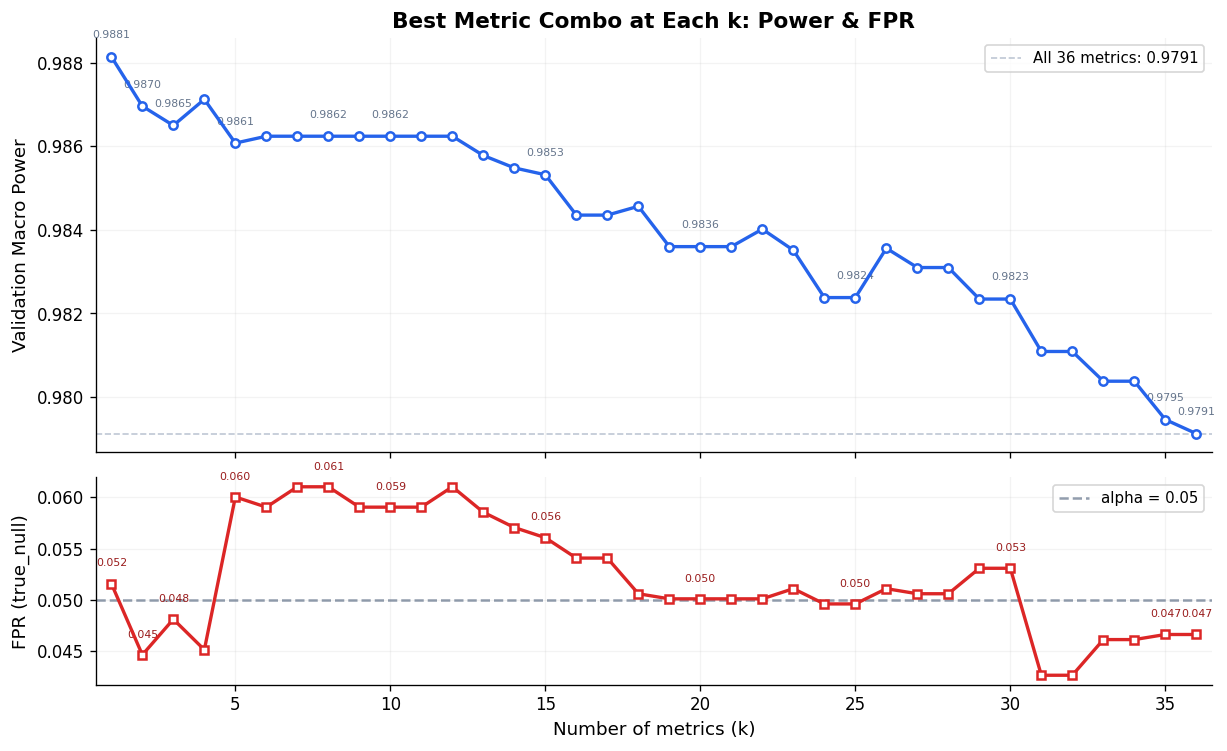

In [329]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True,
                                gridspec_kw={'height_ratios': [2, 1], 'hspace': 0.08})

ks = best_per_k['k'].values
powers = best_per_k['val_macro_power'].values
fprs = best_per_k['val_FPR'].values

# Top: Power
ax1.plot(ks, powers, '-o', color='#2563eb', markersize=5, lw=2, zorder=4,
         markerfacecolor='white', markeredgewidth=1.5)
ax1.axhline(FULL_POWER, color='#94a3b8', ls='--', lw=1, alpha=0.6,
            label=f'All {len(SAFE_METRICS)} metrics: {FULL_POWER:.4f}')
ax1.set_ylabel('Validation Macro Power', fontsize=11)
ax1.set_title('Best Metric Combo at Each k: Power & FPR', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.15)
ax1.legend(fontsize=9)

# Label only every few k to avoid overlap
label_ks = set([1, 2, 3, 5, 8, 10, 15, 20, 25, 30, 35, 40, ks[-1]])
for _, row in best_per_k.iterrows():
    k_val = int(row['k'])
    if k_val in label_ks:
        ax1.text(k_val, row['val_macro_power'] + 0.0004, f'{row["val_macro_power"]:.4f}',
                 fontsize=6.5, color='#64748b', ha='center', va='bottom')

# Bottom: FPR
ax2.plot(ks, fprs, '-s', color='#dc2626', markersize=5, lw=2, zorder=4,
         markerfacecolor='white', markeredgewidth=1.5)
ax2.axhline(ALPHA, color='#64748b', ls='--', lw=1.5, alpha=0.7, label=f'alpha = {ALPHA}')
ax2.set_xlabel('Number of metrics (k)', fontsize=11)
ax2.set_ylabel('FPR (true_null)', fontsize=11)
ax2.set_xlim(0.5, ks[-1] + 0.5)
ax2.grid(True, alpha=0.15)
ax2.legend(fontsize=9)

for _, row in best_per_k.iterrows():
    k_val = int(row['k'])
    if k_val in label_ks:
        ax2.text(k_val, row['val_FPR'] + 0.0015, f'{row["val_FPR"]:.3f}',
                 fontsize=6.5, color='#991b1b', ha='center', va='bottom')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(OUT_DIR / 'best_per_k.png', dpi=200, bbox_inches='tight')
plt.show()

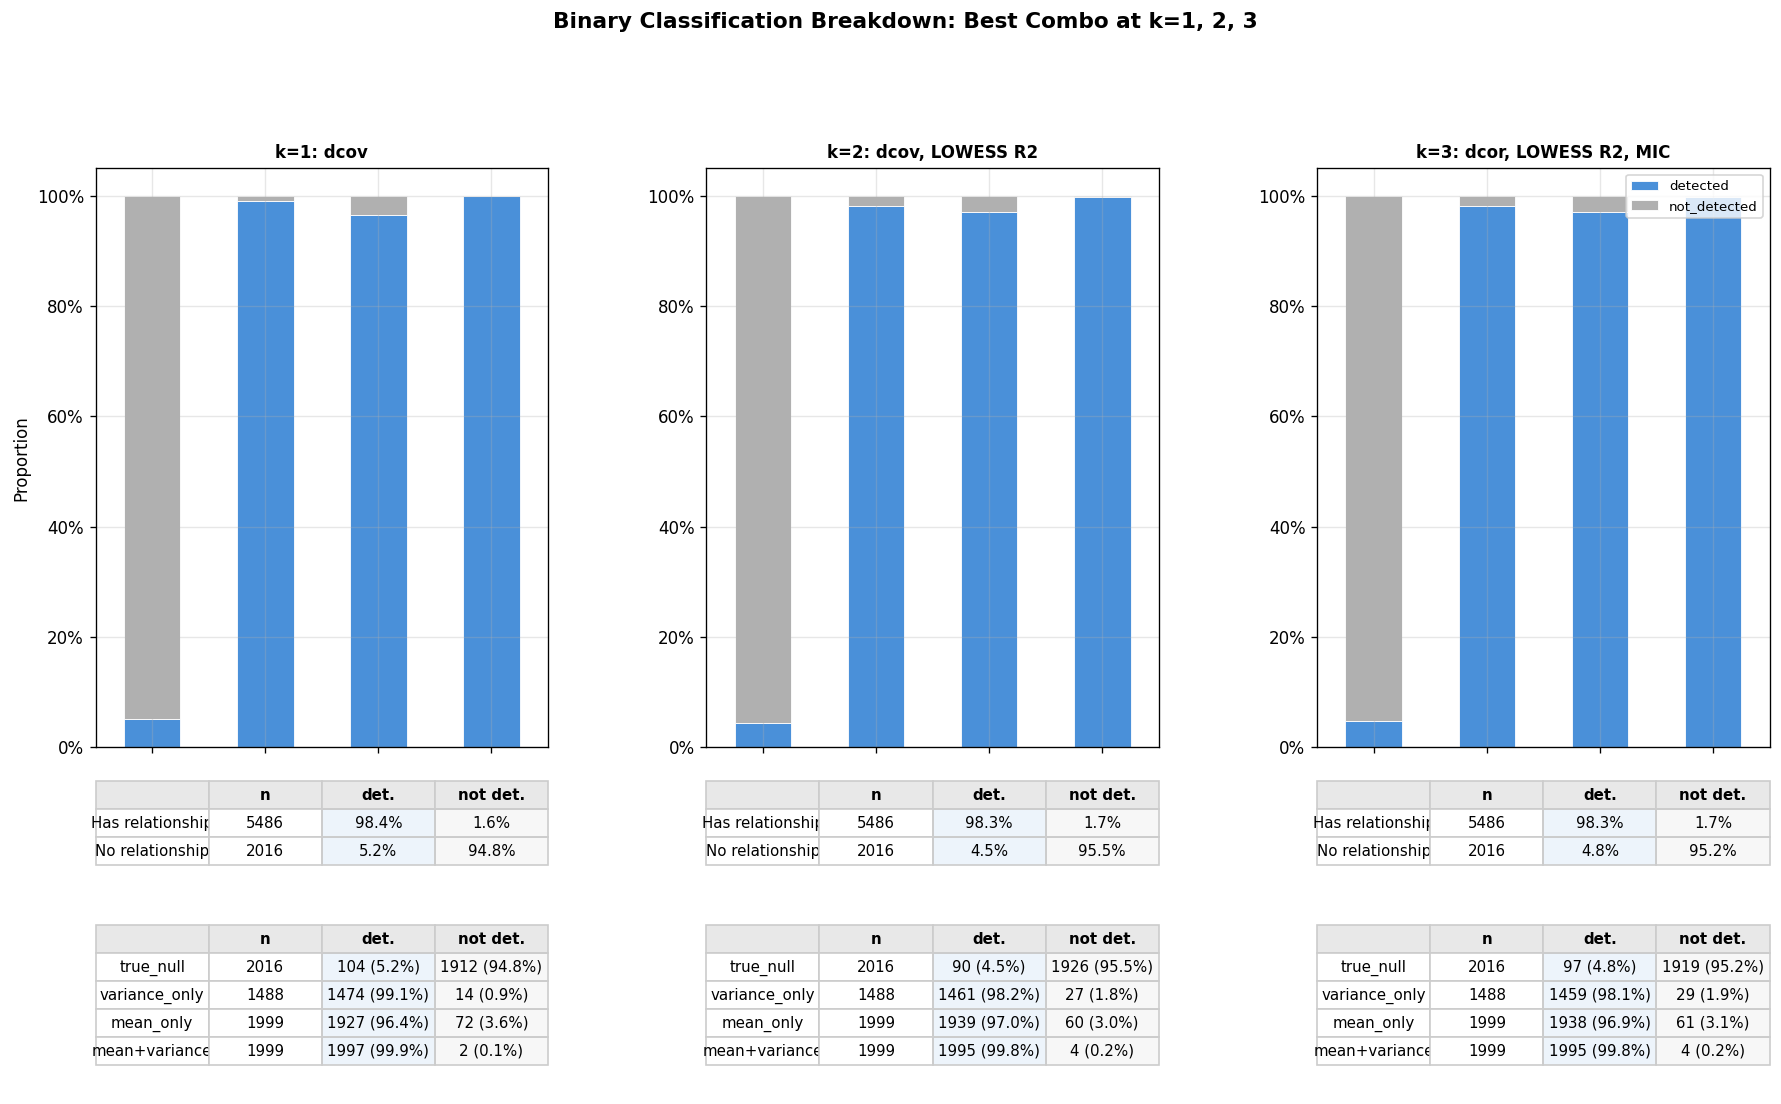

In [330]:
# ── Binary classification breakdown for best k=1, 2, 3 ──
cat_order = ['true_null', 'variance_only', 'mean_only', 'mean+variance']
bin_order = ['detected', 'not_detected']
colors_bin = {'detected': '#4a90d9', 'not_detected': '#b0b0b0'}
grp_def = {'Has relationship': ['mean_only', 'variance_only', 'mean+variance'],
           'No relationship': ['true_null']}

top_k_combos = best_per_k[best_per_k['k'].isin([1, 2, 3])].sort_values('k')

fig, axes_grid = plt.subplots(3, 3, figsize=(18, 10),
    gridspec_kw={'height_ratios': [3, 0.6, 1], 'hspace': 0.06, 'wspace': 0.35})

for col_i, (_, combo_row) in enumerate(top_k_combos.iterrows()):
    k_val = int(combo_row['k'])
    z_metrics = combo_row['metrics'].split(',')
    display = combo_row['display_metrics']

    null_T = compute_null_T(train, z_metrics)
    T_val = validation[z_metrics].max(axis=1).values
    p_val = compute_pvalues(T_val, null_T)
    detected = p_val <= ALPHA

    val_cls = pd.Series(np.where(detected, 'detected', 'not_detected'),
                        index=validation.index)
    val_cat = validation['category']

    ax_bar = axes_grid[0, col_i]
    ax_tbl1 = axes_grid[1, col_i]
    ax_tbl2 = axes_grid[2, col_i]

    # ── Bar chart ──
    ct = pd.crosstab(val_cat, val_cls, normalize='index')
    ct = ct.reindex(index=cat_order, columns=bin_order, fill_value=0)
    ct.plot.bar(stacked=True, ax=ax_bar,
                color=[colors_bin[c] for c in bin_order],
                edgecolor='white', linewidth=0.5, legend=False)
    ax_bar.set_title(f'k={k_val}: {display}', fontsize=10, fontweight='bold')
    ax_bar.set_ylabel('Proportion' if col_i == 0 else '')
    ax_bar.set_xlabel('')
    ax_bar.set_xticklabels([])
    ax_bar.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    if col_i == 2:
        ax_bar.legend(loc='upper right', fontsize=8)

    ct_counts = pd.crosstab(val_cat, val_cls).reindex(
        index=cat_order, columns=bin_order, fill_value=0)
    ct_pct = (ct * 100).round(1)

    # ── Table 1: 2-row summary ──
    ax_tbl1.axis('off')
    col_labels = ['', 'n', 'det.', 'not det.']
    rows_grp = []
    for label, cats in grp_def.items():
        mask = val_cat.isin(cats)
        n_grp = mask.sum()
        row = [label, str(n_grp)]
        for cls in bin_order:
            cnt = int((val_cls[mask] == cls).sum())
            pct = cnt / n_grp * 100
            row.append(f'{pct:.1f}%')
        rows_grp.append(row)
    t1 = ax_tbl1.table(cellText=rows_grp, colLabels=col_labels,
                        loc='center', cellLoc='center')
    t1.auto_set_font_size(False)
    t1.set_fontsize(9)
    t1.scale(1, 1.4)
    for (r, c), cell in t1.get_celld().items():
        cell.set_edgecolor('#cccccc')
        if r == 0:
            cell.set_facecolor('#e8e8e8')
            cell.set_text_props(fontweight='bold')
        elif c >= 2:
            cell.set_facecolor(colors_bin[bin_order[c - 2]] + '18')

    # ── Table 2: 4-row per category ──
    ax_tbl2.axis('off')
    rows_cat = []
    for cat in cat_order:
        n_cat = int(ct_counts.loc[cat].sum())
        row = [cat, str(n_cat)]
        for cls in bin_order:
            cnt = int(ct_counts.loc[cat, cls])
            pct = ct_pct.loc[cat, cls]
            row.append(f'{cnt} ({pct:.1f}%)')
        rows_cat.append(row)
    t2 = ax_tbl2.table(cellText=rows_cat, colLabels=col_labels,
                        loc='center', cellLoc='center')
    t2.auto_set_font_size(False)
    t2.set_fontsize(9)
    t2.scale(1, 1.4)
    for (r, c), cell in t2.get_celld().items():
        cell.set_edgecolor('#cccccc')
        if r == 0:
            cell.set_facecolor('#e8e8e8')
            cell.set_text_props(fontweight='bold')
        elif c >= 2:
            cell.set_facecolor(colors_bin[bin_order[c - 2]] + '18')

plt.suptitle('Binary Classification Breakdown: Best Combo at k=1, 2, 3',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(OUT_DIR / 'best_k123_breakdown.png', dpi=200, bbox_inches='tight')
plt.show()

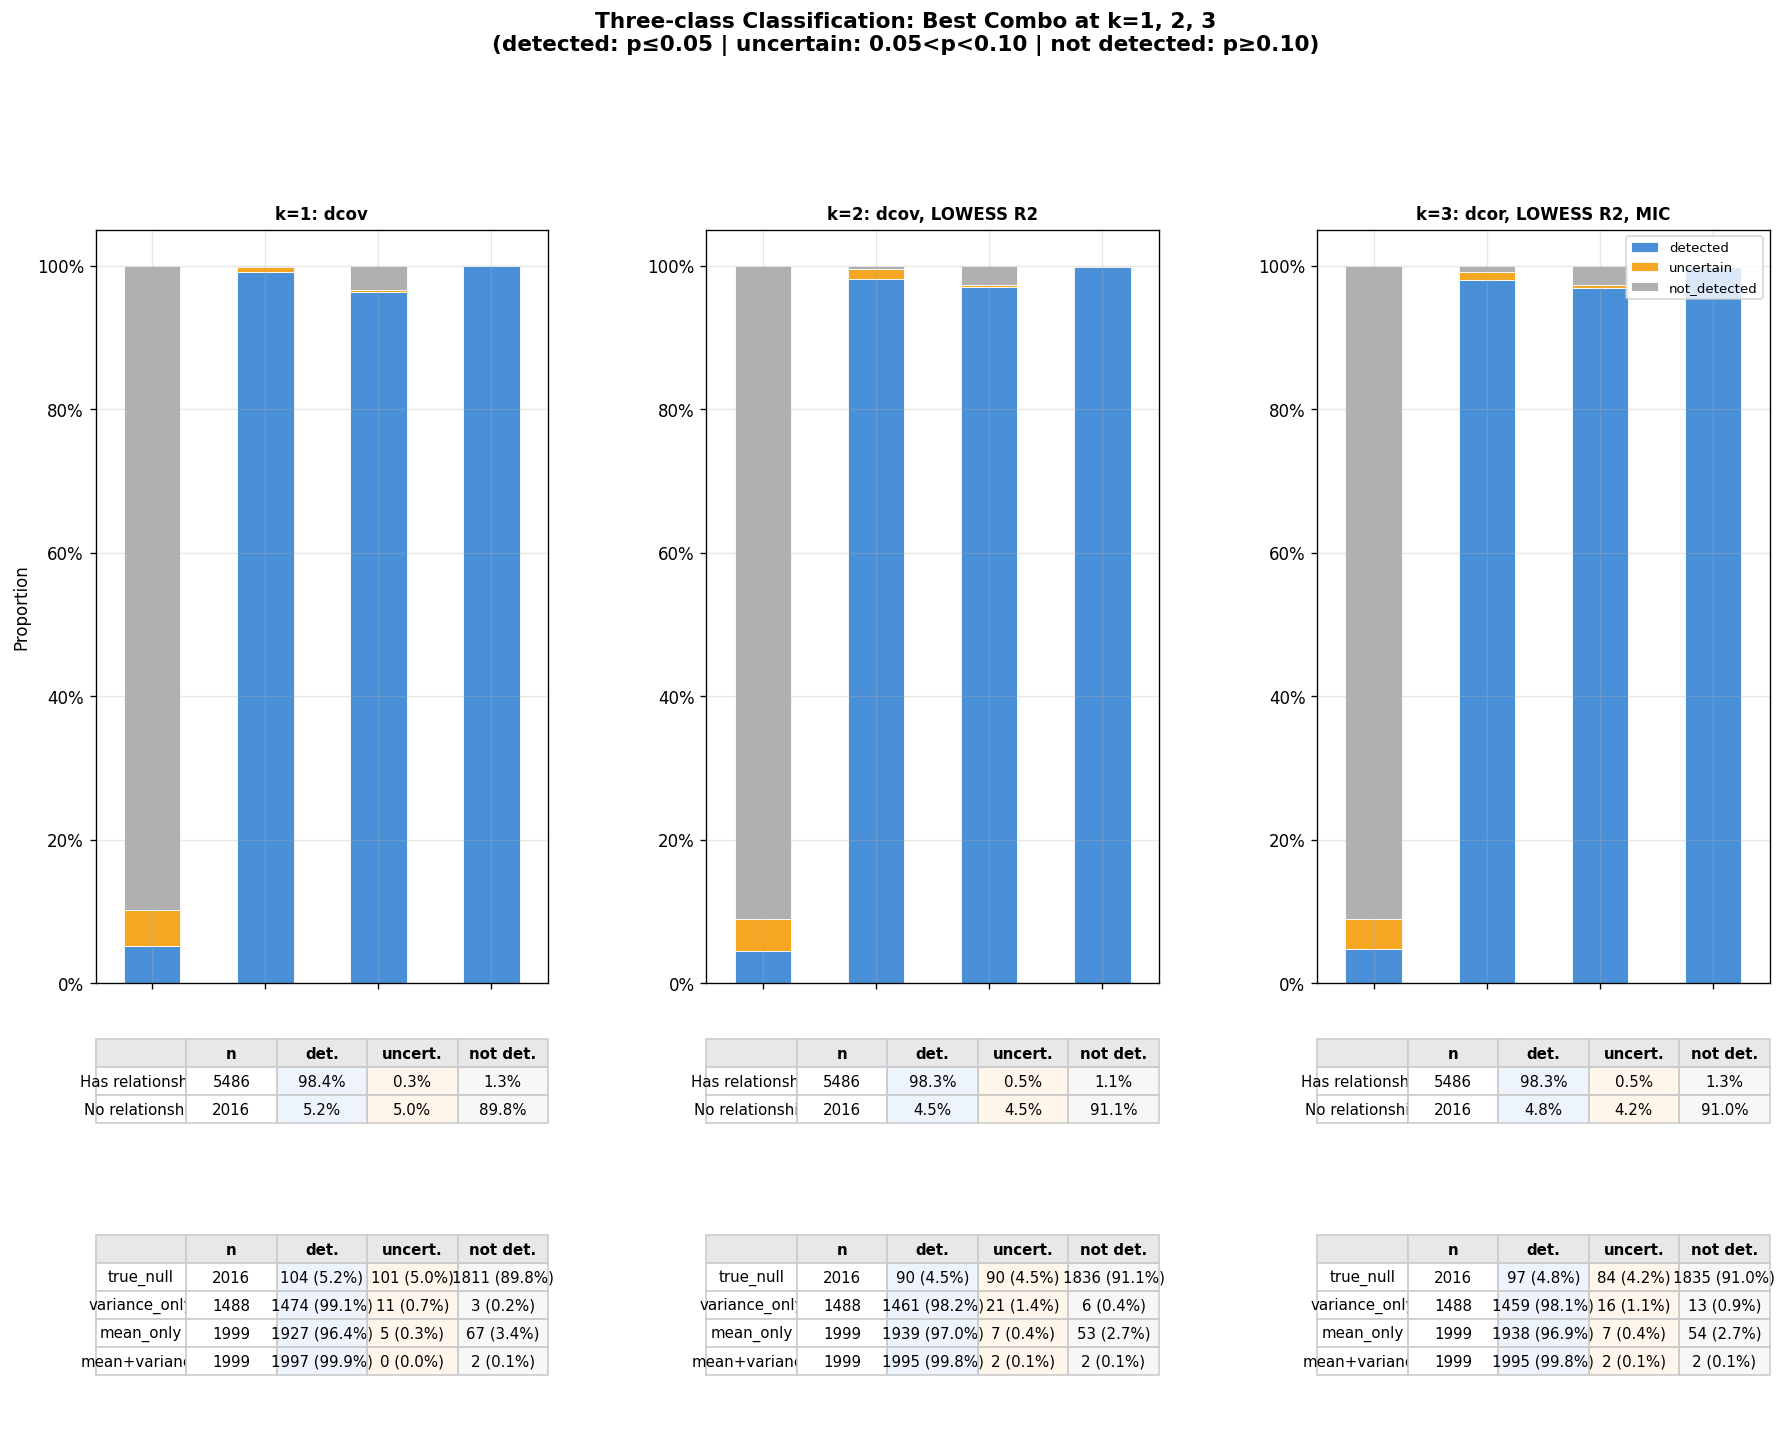

=== Uncertain case counts ===
  k=1: 117 uncertain (1.6%)
  k=2: 120 uncertain (1.6%)
  k=3: 109 uncertain (1.5%)


In [331]:
# ── Three-class classification (with uncertain) for best k=1, 2, 3 ──
ALPHA_LO, ALPHA_HI = 0.05, 0.10
cls3_order = ['detected', 'uncertain', 'not_detected']
colors3 = {'detected': '#4a90d9', 'uncertain': '#f5a623', 'not_detected': '#b0b0b0'}

fig, axes_grid = plt.subplots(3, 3, figsize=(18, 13),
    gridspec_kw={'height_ratios': [3, 0.6, 1], 'hspace': 0.06, 'wspace': 0.35})

for col_i, (_, combo_row) in enumerate(top_k_combos.iterrows()):
    k_val = int(combo_row['k'])
    z_metrics = combo_row['metrics'].split(',')
    display = combo_row['display_metrics']

    null_T = compute_null_T(train, z_metrics)
    T_val = validation[z_metrics].max(axis=1).values
    p_val = compute_pvalues(T_val, null_T)

    cls3 = np.where(p_val <= ALPHA_LO, 'detected',
                    np.where(p_val >= ALPHA_HI, 'not_detected', 'uncertain'))
    cls3_series = pd.Series(cls3, index=validation.index)
    val_cat = validation['category']

    ax_bar = axes_grid[0, col_i]
    ax_tbl1 = axes_grid[1, col_i]
    ax_tbl2 = axes_grid[2, col_i]

    # ── Bar chart ──
    ct = pd.crosstab(val_cat, cls3_series, normalize='index')
    ct = ct.reindex(index=cat_order, columns=cls3_order, fill_value=0)
    ct.plot.bar(stacked=True, ax=ax_bar,
                color=[colors3[c] for c in cls3_order],
                edgecolor='white', linewidth=0.5, legend=False)
    ax_bar.set_title(f'k={k_val}: {display}', fontsize=10, fontweight='bold')
    ax_bar.set_ylabel('Proportion' if col_i == 0 else '')
    ax_bar.set_xlabel('')
    ax_bar.set_xticklabels([])
    ax_bar.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
    if col_i == 2:
        ax_bar.legend(loc='upper right', fontsize=8)

    ct_counts = pd.crosstab(val_cat, cls3_series)
    ct_counts = ct_counts.reindex(index=cat_order, columns=cls3_order, fill_value=0)
    ct_pct = (ct * 100).round(1)

    # ── Table 1: 2-row summary ──
    ax_tbl1.axis('off')
    col_labels = ['', 'n', 'det.', 'uncert.', 'not det.']
    rows_grp = []
    for label, cats in grp_def.items():
        mask = val_cat.isin(cats)
        n_grp = mask.sum()
        row = [label, str(n_grp)]
        for cls in cls3_order:
            cnt = int((cls3_series[mask] == cls).sum())
            pct = cnt / n_grp * 100
            row.append(f'{pct:.1f}%')
        rows_grp.append(row)
    t1 = ax_tbl1.table(cellText=rows_grp, colLabels=col_labels,
                        loc='center', cellLoc='center')
    t1.auto_set_font_size(False)
    t1.set_fontsize(9)
    t1.scale(1, 1.4)
    for (r, c), cell in t1.get_celld().items():
        cell.set_edgecolor('#cccccc')
        if r == 0:
            cell.set_facecolor('#e8e8e8')
            cell.set_text_props(fontweight='bold')
        elif c >= 2:
            cell.set_facecolor(colors3[cls3_order[c - 2]] + '18')

    # ── Table 2: 4-row per category ──
    ax_tbl2.axis('off')
    rows_cat = []
    for cat in cat_order:
        n_cat = int(ct_counts.loc[cat].sum())
        row = [cat, str(n_cat)]
        for cls in cls3_order:
            cnt = int(ct_counts.loc[cat, cls])
            pct = ct_pct.loc[cat, cls]
            row.append(f'{cnt} ({pct:.1f}%)')
        rows_cat.append(row)
    t2 = ax_tbl2.table(cellText=rows_cat, colLabels=col_labels,
                        loc='center', cellLoc='center')
    t2.auto_set_font_size(False)
    t2.set_fontsize(9)
    t2.scale(1, 1.4)
    for (r, c), cell in t2.get_celld().items():
        cell.set_edgecolor('#cccccc')
        if r == 0:
            cell.set_facecolor('#e8e8e8')
            cell.set_text_props(fontweight='bold')
        elif c >= 2:
            cell.set_facecolor(colors3[cls3_order[c - 2]] + '18')

plt.suptitle('Three-class Classification: Best Combo at k=1, 2, 3\n'
             '(detected: p≤0.05 | uncertain: 0.05<p<0.10 | not detected: p≥0.10)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
fig.savefig(OUT_DIR / 'best_k123_threeclass.png', dpi=200, bbox_inches='tight')
plt.show()

# ── Print uncertain summary ──
print('=== Uncertain case counts ===')
for _, combo_row in top_k_combos.iterrows():
    k_val = int(combo_row['k'])
    z_metrics = combo_row['metrics'].split(',')
    null_T = compute_null_T(train, z_metrics)
    T_val = validation[z_metrics].max(axis=1).values
    p_val = compute_pvalues(T_val, null_T)
    n_unc = int(((p_val > ALPHA_LO) & (p_val < ALPHA_HI)).sum())
    print(f'  k={k_val}: {n_unc} uncertain ({n_unc/len(p_val):.1%})')

## §10 Final recommendation

Three outputs:
1. **Best-power combo** — highest train macro power (selected on train, reported on validation)
2. **Parsimonious combo** — smallest k within 0.5pp of best validation power
3. **dcor alone** — reference baseline for simplicity

In [332]:
all_combos = pd.concat([exact_best, backward, forward, beam_best],
                        ignore_index=True, sort=False).dropna(subset=['train_macro_power'])

eligible = all_combos[all_combos['val_FPR'] <= 0.08].copy()

# 1. Best-power (by train selection)
best_power_row = eligible.sort_values('train_macro_power', ascending=False).iloc[0]

# 2. Parsimonious: smallest k with val_macro_power within 0.005 of best
best_val = eligible['val_macro_power'].max()
near_best = eligible[eligible['val_macro_power'] >= best_val - 0.005]
parsimonious_row = near_best.sort_values('k').iloc[0]

# 3. dcor alone
dcor_row = make_row(['z_dcor'], label='dcor alone', kind='reference')

print('=' * 70)
print('RECOMMENDATIONS')
print('=' * 70)

print(f'\n1. Best-power combo (selected by train macro power):')
print(f'   k = {int(best_power_row["k"])}')
print(f'   metrics: {best_power_row["display_metrics"]}')
print(f'   val macro power: {best_power_row["val_macro_power"]:.4f}')
print(f'   val FPR: {best_power_row["val_FPR"]:.4f}')
print(f'   MO={best_power_row["val_MO"]:.3f}  VO={best_power_row["val_VO"]:.3f}  MV={best_power_row["val_MV"]:.3f}')

print(f'\n2. Parsimonious combo (smallest k near best):')
print(f'   k = {int(parsimonious_row["k"])}')
print(f'   metrics: {parsimonious_row["display_metrics"]}')
print(f'   val macro power: {parsimonious_row["val_macro_power"]:.4f}')
print(f'   val FPR: {parsimonious_row["val_FPR"]:.4f}')

print(f'\n3. Reference - dcor alone:')
print(f'   val macro power: {dcor_row["val_macro_power"]:.4f}')
print(f'   val FPR: {dcor_row["val_FPR"]:.4f}')
print(f'   MO={dcor_row["val_MO"]:.3f}  VO={dcor_row["val_VO"]:.3f}  MV={dcor_row["val_MV"]:.3f}')

rec = {
    'best_power': {
        'k': int(best_power_row['k']),
        'metrics': best_power_row['display_metrics'],
        'val_macro_power': round(float(best_power_row['val_macro_power']), 4),
        'val_FPR': round(float(best_power_row['val_FPR']), 4),
    },
    'parsimonious': {
        'k': int(parsimonious_row['k']),
        'metrics': parsimonious_row['display_metrics'],
        'val_macro_power': round(float(parsimonious_row['val_macro_power']), 4),
        'val_FPR': round(float(parsimonious_row['val_FPR']), 4),
    },
    'dcor_alone': {
        'val_macro_power': round(float(dcor_row['val_macro_power']), 4),
        'val_FPR': round(float(dcor_row['val_FPR']), 4),
    },
}
with open(OUT_DIR / 'recommendation.json', 'w') as f:
    json.dump(rec, f, indent=2)
print(f'\nSaved to {OUT_DIR}/recommendation.json')

RECOMMENDATIONS

1. Best-power combo (selected by train macro power):
   k = 8
   metrics: |Pearson|, abs_std_pf_overall, dcor, ec_bin_amp, ew_bin_amp, LOWESS R2, MEV, MIC-r2
   val macro power: 0.9862
   val FPR: 0.0610
   MO=0.972  VO=0.976  MV=0.998

2. Parsimonious combo (smallest k near best):
   k = 1
   metrics: dcor
   val macro power: 0.9881
   val FPR: 0.0516

3. Reference - dcor alone:
   val macro power: 0.9881
   val FPR: 0.0516
   MO=0.964  VO=0.991  MV=0.999

Saved to output/S3.3/recommendation.json


## §10.5 Driver analysis — individual power vs max-Z contribution

Two complementary views of metric importance:
- **Individual power**: which metric is best when used *alone*? → measures standalone discriminability
- **Driver frequency**: in the combined max-Z test, which metric most often provides the *highest Z*? → measures contribution to the ensemble

These can differ because a metric with very high signal Z-scores (frequent driver) may also
have a wide null distribution (lower standalone power). Conversely, a metric with moderate
but tightly-distributed Z-scores can have high standalone power without being the max-Z driver.

In [333]:
# ── Driver analysis: which metric provides max Z for detected cases? ──
# Use the recommended combo's metrics for the combined test,
# but compute drivers across ALL safe metrics to show the full picture.

val_signal = validation[validation['category'] != 'true_null'].copy()
z_safe = [c for c in SAFE_METRICS if c in val_signal.columns]

# For each signal case: which metric has the highest Z?
best_z_metric = val_signal[z_safe].idxmax(axis=1).str.replace('z_', '', regex=False)
driver_counts = best_z_metric.value_counts()
driver_pct = (driver_counts / len(val_signal) * 100).round(1)

# Individual power ranking (from §5)
ind_rank = individual.set_index('label')['val_macro_power'].to_dict()

# Build comparison table
driver_df = pd.DataFrame({
    'metric': driver_pct.index,
    'driver_freq': driver_pct.values,
}).head(15)
driver_df['display'] = driver_df['metric'].map(
    lambda m: METRIC_DISPLAY.get(f'z_{m}', m))
driver_df['individual_power'] = driver_df['display'].map(
    lambda d: ind_rank.get(d, np.nan))
driver_df['individual_power_pct'] = (driver_df['individual_power'] * 100).round(1)

print('=== Top max-Z drivers (validation signal cases) ===')
print(f'{"Metric":25s} {"Driver %":>10s} {"Indiv. Power":>14s}')
print('-' * 52)
for _, row in driver_df.iterrows():
    ip = f'{row["individual_power_pct"]:.1f}%' if not np.isnan(row['individual_power_pct']) else 'N/A'
    print(f'{row["display"]:25s} {row["driver_freq"]:>9.1f}% {ip:>14s}')

print(f'\nKey insight:')
print(f'  LOWESS R2 is the most frequent driver (~{driver_pct.get("lowess_r2", 0):.0f}% of cases)')
print(f'  but dcor has the highest individual power (~{ind_rank.get("dcor", 0):.1%})')
print(f'  → high signal Z ≠ high standalone power (null distribution width matters)')

=== Top max-Z drivers (validation signal cases) ===
Metric                      Driver %   Indiv. Power
----------------------------------------------------
LOWESS R2                      46.8%          74.3%
eta2(EW)                       12.4%          74.9%
MAS                            12.3%          67.5%
dcor                            9.6%          98.8%
dcov                            7.5%          98.8%
eta2(EC)                        3.3%          74.1%
Wass(EC)                        1.9%          90.6%
Wass(EW)                        1.7%          90.4%
MIC-r2                          1.5%          49.4%
MEV                             1.2%          92.2%
MIC                             0.4%          94.3%
ew_bin_amp                      0.2%          70.9%
KS(EW)                          0.2%          90.5%
KS(EC)                          0.1%          90.8%
abs_std_ep_mid                  0.1%           2.7%

Key insight:
  LOWESS R2 is the most frequent driver (~47% of 

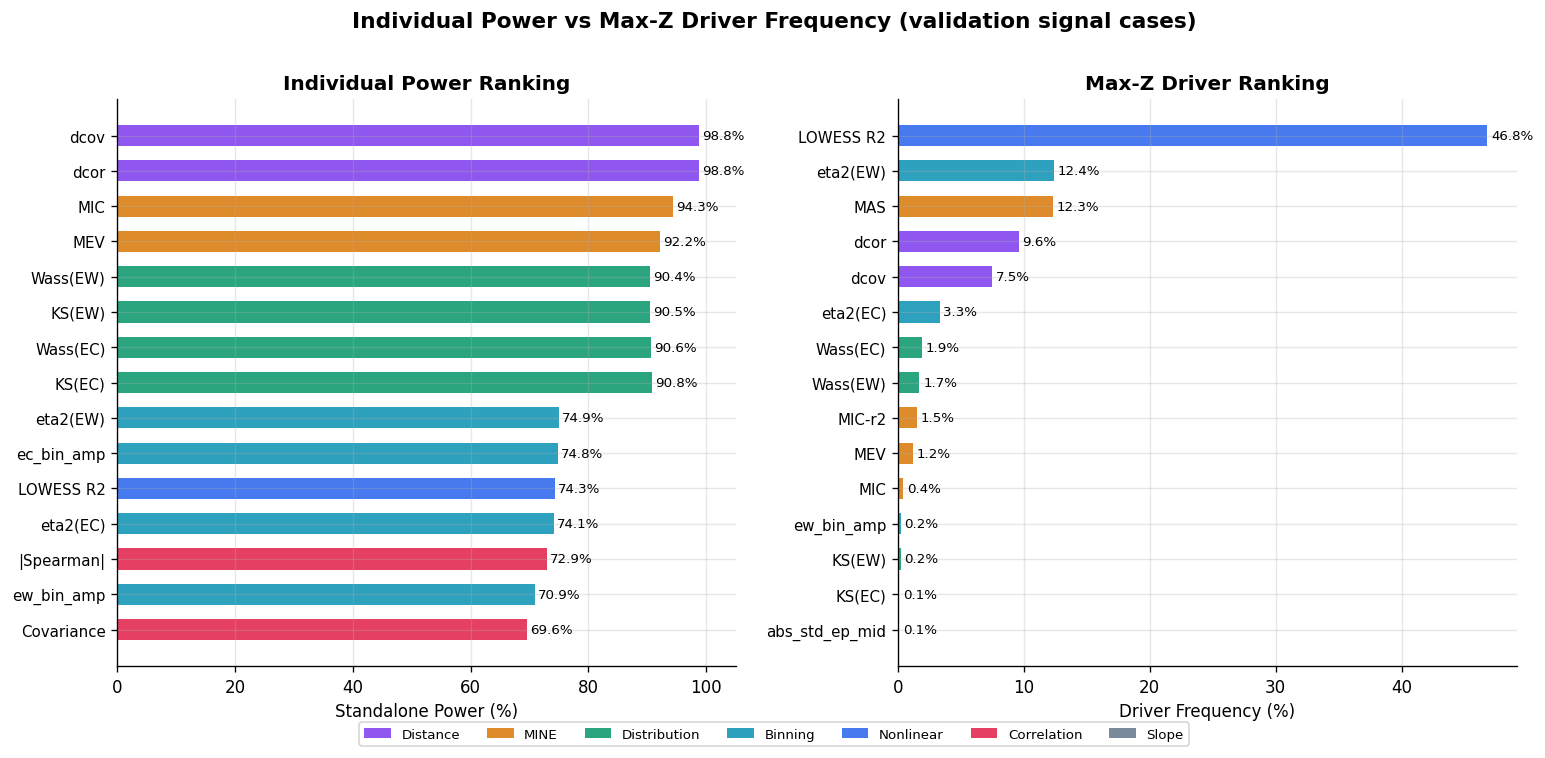

In [334]:
# ── Side-by-side: Individual Power vs Driver Frequency ──
top_n = min(15, len(driver_df))
plot_df = driver_df.head(top_n).copy()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 6))

# Left: Individual power ranking (top 15)
ind_top = individual.head(top_n).copy()
colors_left = [GROUP_COLORS.get(g, '#999') for g in ind_top['group'].values]
ax1.barh(range(top_n), ind_top['val_macro_power'].values * 100,
         color=colors_left, alpha=0.85, height=0.6)
ax1.set_yticks(range(top_n))
ax1.set_yticklabels(ind_top['label'].values, fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('Standalone Power (%)')
ax1.set_title('Individual Power Ranking', fontsize=12, fontweight='bold')
ax1.set_xlim(0, 105)
for i, p in enumerate(ind_top['val_macro_power'].values):
    ax1.text(p * 100 + 0.5, i, f'{p:.1%}', va='center', fontsize=8)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# Right: Driver frequency ranking (top 15)
colors_right = []
for m in plot_df['metric'].values:
    zc = f'z_{m}'
    g = METRIC_GROUPS.get(zc, '')
    colors_right.append(GROUP_COLORS.get(g, '#999'))
ax2.barh(range(top_n), plot_df['driver_freq'].values,
         color=colors_right, alpha=0.85, height=0.6)
ax2.set_yticks(range(top_n))
ax2.set_yticklabels(plot_df['display'].values, fontsize=9)
ax2.invert_yaxis()
ax2.set_xlabel('Driver Frequency (%)')
ax2.set_title('Max-Z Driver Ranking', fontsize=12, fontweight='bold')
for i, p in enumerate(plot_df['driver_freq'].values):
    ax2.text(p + 0.3, i, f'{p:.1f}%', va='center', fontsize=8)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# Shared legend
seen = []
handles = []
for g in list(ind_top['group'].values) + [METRIC_GROUPS.get(f'z_{m}', '') for m in plot_df['metric'].values]:
    if g and g not in seen:
        seen.append(g)
        handles.append(Patch(facecolor=GROUP_COLORS.get(g, '#999'),
                             label=GROUP_LABELS.get(g, g), alpha=0.85))
fig.legend(handles=handles, loc='lower center', ncol=len(handles), fontsize=8,
           bbox_to_anchor=(0.5, -0.02))

plt.suptitle('Individual Power vs Max-Z Driver Frequency (validation signal cases)',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
fig.savefig(OUT_DIR / 'power_vs_driver.png', dpi=200, bbox_inches='tight')
plt.show()

In [335]:
# ── Driver breakdown by category ──
print('=== Max-Z driver by category (top 5 per category) ===\n')
for cat in ['mean_only', 'variance_only', 'mean+variance']:
    sub = validation[validation['category'] == cat]
    drivers = sub[z_safe].idxmax(axis=1).str.replace('z_', '', regex=False)
    top5 = drivers.value_counts().head(5)
    print(f'{cat} (n={len(sub)}):')
    for m, cnt in top5.items():
        display = METRIC_DISPLAY.get(f'z_{m}', m)
        print(f'  {display:25s} {cnt:5d}  ({cnt/len(sub):.1%})')
    print()

# Median Z comparison for top metrics
print('=== Median Z-score: signal vs null ===')
print(f'{"Metric":20s} {"true_null":>10s} {"mean_only":>10s} {"var_only":>10s} {"mean+var":>10s}  {"null std":>10s}')
print('-' * 75)
for zc in ['z_lowess_r2', 'z_dcor', 'z_mic', 'z_ew_bin_eta2', 'z_ec_bin_eta2', 'z_ec_dist_wass']:
    tn_med = validation.loc[validation['category']=='true_null', zc].median()
    mo_med = validation.loc[validation['category']=='mean_only', zc].median()
    vo_med = validation.loc[validation['category']=='variance_only', zc].median()
    mv_med = validation.loc[validation['category']=='mean+variance', zc].median()
    tn_std = validation.loc[validation['category']=='true_null', zc].std()
    d = METRIC_DISPLAY.get(zc, zc)
    print(f'{d:20s} {tn_med:10.2f} {mo_med:10.2f} {vo_med:10.2f} {mv_med:10.2f}  {tn_std:10.2f}')

print('\n→ LOWESS R2 has highest signal Z but also wider null distribution')
print('→ dcor has lower signal Z but very tight null → better standalone discrimination')

=== Max-Z driver by category (top 5 per category) ===

mean_only (n=1999):
  LOWESS R2                  1356  (67.8%)
  eta2(EW)                    355  (17.8%)
  eta2(EC)                     82  (4.1%)
  dcor                         66  (3.3%)
  dcov                         44  (2.2%)

variance_only (n=1488):
  MAS                         635  (42.7%)
  dcor                        296  (19.9%)
  dcov                        229  (15.4%)
  MIC-r2                       82  (5.5%)
  Wass(EC)                     75  (5.0%)

mean+variance (n=1999):
  LOWESS R2                  1208  (60.4%)
  eta2(EW)                    324  (16.2%)
  dcor                        162  (8.1%)
  dcov                        136  (6.8%)
  eta2(EC)                     97  (4.9%)

=== Median Z-score: signal vs null ===
Metric                true_null  mean_only   var_only   mean+var    null std
---------------------------------------------------------------------------
LOWESS R2                 -0.02      59.51   

## §11 Backward elimination curve

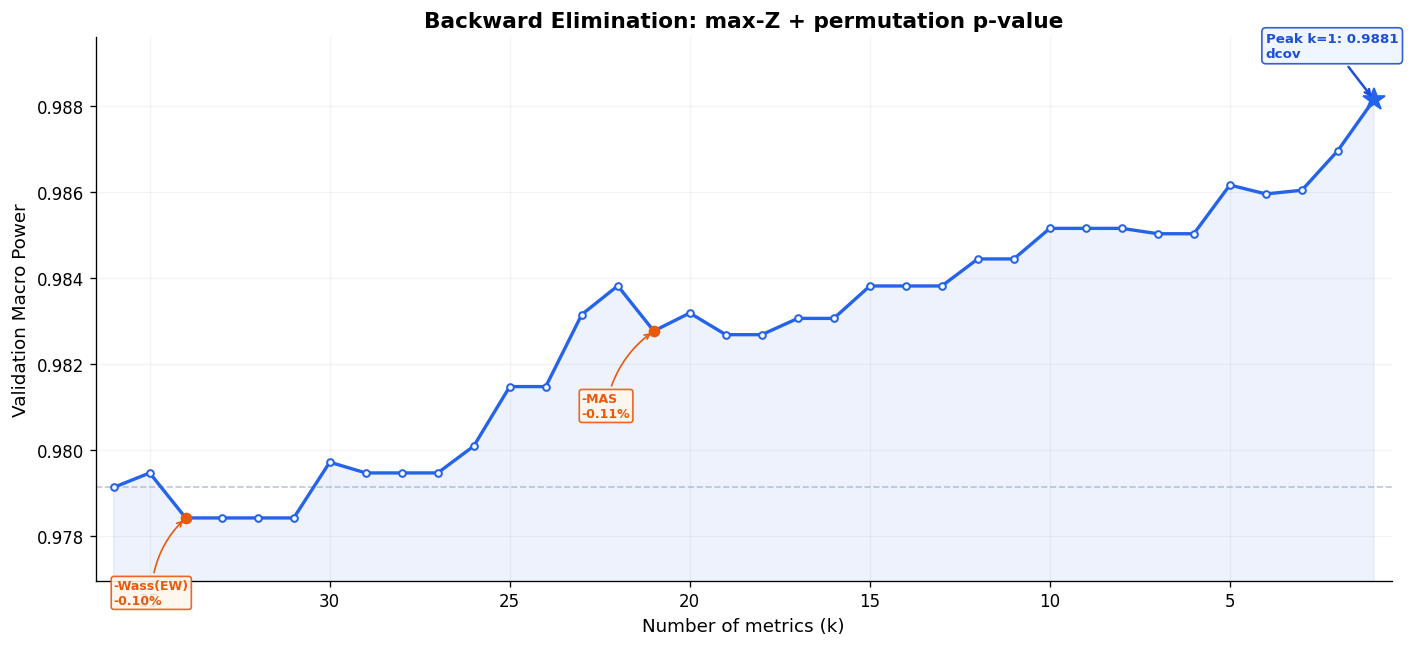

In [336]:
fig, ax = plt.subplots(figsize=(12, 5.5))

bk = backward.copy()
ks_b = bk['k'].values
powers_b = bk['val_macro_power'].values
k_max = int(ks_b[0])

ax.fill_between(ks_b, powers_b, alpha=0.08, color='#2563eb')
ax.plot(ks_b, powers_b, '-o', color='#2563eb', markersize=4, lw=2, zorder=4,
        markerfacecolor='white', markeredgewidth=1.2)
ax.axhline(FULL_POWER, color='#94a3b8', ls='--', lw=1, alpha=0.6)

peak_bk = bk.loc[bk['val_macro_power'].idxmax()]
ax.plot(int(peak_bk['k']), peak_bk['val_macro_power'], '*', color='#2563eb', markersize=14, zorder=6)
ax.annotate(f'Peak k={int(peak_bk["k"])}: {peak_bk["val_macro_power"]:.4f}\n{peak_bk["display_metrics"]}',
             xy=(int(peak_bk['k']), peak_bk['val_macro_power']),
             xytext=(int(peak_bk['k']) + 3, peak_bk['val_macro_power'] + 0.001),
             fontsize=8, fontweight='bold', color='#1d4ed8',
             arrowprops=dict(arrowstyle='->', color='#1d4ed8', lw=1.5),
             bbox=dict(boxstyle='round,pad=0.3', facecolor='#eff6ff',
                       edgecolor='#1d4ed8', alpha=0.9), zorder=7)

drops = bk[bk['power_change'].fillna(0) < -0.001]
for _, row in drops.iterrows():
    ax.plot(int(row['k']), row['val_macro_power'], 'o', color='#ea580c', markersize=6, zorder=6)
    ax.annotate(f'-{row["removed"]}\n{row["power_change"]:+.2%}',
                xy=(int(row['k']), row['val_macro_power']),
                xytext=(int(row['k']) + 2, row['val_macro_power'] - 0.002),
                fontsize=7.5, color='#ea580c', fontweight='bold',
                arrowprops=dict(arrowstyle='->', color='#ea580c', lw=1,
                                connectionstyle='arc3,rad=-0.2'),
                bbox=dict(boxstyle='round,pad=0.2', facecolor='#fff7ed',
                          edgecolor='#ea580c', alpha=0.9), zorder=7)

ax.set_xlabel('Number of metrics (k)', fontsize=11)
ax.set_ylabel('Validation Macro Power', fontsize=11)
ax.set_title('Backward Elimination: max-Z + permutation p-value', fontsize=13, fontweight='bold')
ax.set_xlim(k_max + 0.5, 0.5)
y_range = powers_b.max() - powers_b.min()
ax.set_ylim(powers_b.min() - y_range * 0.15, powers_b.max() + y_range * 0.15)
ax.grid(True, alpha=0.15)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
fig.savefig(OUT_DIR / 'backward_elimination.png', dpi=200, bbox_inches='tight')
plt.show()

## §12 Summary

In [337]:
print('=' * 70)
print('C_S3.3 Metric Selection Summary')
print('=' * 70)
print(f'Framework: T = max(Z), p-value via permutation, detect if p <= {ALPHA}')
print(f'Cases: {len(df):,} | Train: {len(train):,} | Validation: {len(validation):,}')
print(f'Safe metrics: {len(SAFE_METRICS)}')
print(f'\nFull-set baseline:')
print(f'  Macro power = {FULL_POWER:.4f}  FPR = {baseline["val_FPR"]:.4f}')
print(f'\n1. Best-power combo: k={int(best_power_row["k"])}')
print(f'   {best_power_row["display_metrics"]}')
print(f'   Macro power = {best_power_row["val_macro_power"]:.4f}  FPR = {best_power_row["val_FPR"]:.4f}')
print(f'\n2. Parsimonious combo: k={int(parsimonious_row["k"])}')
print(f'   {parsimonious_row["display_metrics"]}')
print(f'   Macro power = {parsimonious_row["val_macro_power"]:.4f}  FPR = {parsimonious_row["val_FPR"]:.4f}')
print(f'\n3. dcor alone:')
print(f'   Macro power = {dcor_row["val_macro_power"]:.4f}  FPR = {dcor_row["val_FPR"]:.4f}')
print(f'\nFor ESM application:')
print(f'  Primary:  dcor alone (simplest, strong baseline, easy to interpret)')
print(f'  Enhanced: best-power combo (marginal gain, more robust to edge cases)')
print(f'\nOutputs saved to {OUT_DIR}/')

C_S3.3 Metric Selection Summary
Framework: T = max(Z), p-value via permutation, detect if p <= 0.05
Cases: 15,008 | Train: 7,506 | Validation: 7,502
Safe metrics: 36

Full-set baseline:
  Macro power = 0.9791  FPR = 0.0466

1. Best-power combo: k=8
   |Pearson|, abs_std_pf_overall, dcor, ec_bin_amp, ew_bin_amp, LOWESS R2, MEV, MIC-r2
   Macro power = 0.9862  FPR = 0.0610

2. Parsimonious combo: k=1
   dcor
   Macro power = 0.9881  FPR = 0.0516

3. dcor alone:
   Macro power = 0.9881  FPR = 0.0516

For ESM application:
  Primary:  dcor alone (simplest, strong baseline, easy to interpret)
  Enhanced: best-power combo (marginal gain, more robust to edge cases)

Outputs saved to output/S3.3/
